In [ ]:
# <eval_forecast.py>
# Parameters
eval_start = "2024-08-01"
eval_end = "2024-09-05"
dataset_choice = "imerg"
eval_vars = "total_precipitation_6hr"
apath = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/"
params_path_old = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'

params_path_new1 = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_shapefile_2024-06-01_2024-08-15_FORECAST28.npz'
params_path_new2 = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_shapefile_2024-06-01_2024-07-30_FORECAST28.npz'
norms_dir = '/Datastorage/saptarishi.dhanuka_asp25/gc_norms/'
plots_dir = 'plots/evals'
latmin, latmax, lonmin, lonmax = 6, 38, 35, 65
plot_timesteps = 7
output_pred_old_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'
output_pred_finetuned_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'

"""
Complete evaluation of forecast against different datasets with rainfall analysis
"""
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import sys
import logging
import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import time
import zarr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap

import jax
import optax

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot, compute_difference_with_targets_sims, plot_sample_from_ds
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import regrid_hres_fine_to_coarse, generate_sample_era5_dataset, grads_fn, parse_args, process_to_graphcast_format, compute_mse, compute_mse_diffs

sys.path.append('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')
import trainer.dataloader
from dist_utils import construct_era5_imerg
from datetime import datetime

In [2]:

# --- Basic Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

output_csv_path = "./forecast_evaluation_mse.csv"

# Define India bounding box
INDIA_BBOX = {'lat_min': 6, 'lat_max': 37, 'lon_min': 68, 'lon_max': 97}

# --- Data and Model Loading ---
logging.info(f"Loading dataset '{dataset_choice}' from {eval_start} to {eval_end}")
if dataset_choice == "imerg":
    apath = '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/'
    dbase,_ = trainer.dataloader.open_databases(apath,None)
    dbase = construct_era5_imerg(dbase)
    # Load a slightly larger window to ensure we have the day before the start_date for initialization
    load_start_date = pd.to_datetime(eval_start) - pd.Timedelta(days=1)
    eval_time_ds = dbase.sel(time=slice(load_start_date.strftime('%Y-%m-%d'), eval_end))
    del dbase


2025-07-31 18:25:59,766 - INFO - Loading dataset 'imerg' from 2024-08-01 to 2024-09-05


Found ['/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/02', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/03', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/04', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/05', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/06', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/07', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/08', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/09', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/10', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/11', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/12', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/02', '/Datastorage

Looping through era5 days for conversion:  71%|███████   | 366/517 [00:06<00:02, 53.82it/s]


Exceeded IMERG timespan, stopped replacing with IMERG
✅ All ERA5 6-hourly values match the converted IMERG values (where IMERG is valid).


In [3]:
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

In [4]:

select_time_eval = process_to_graphcast_format(eval_time_ds)
logging.info(f"Full data range loaded: {select_time_eval.time.values[0]} to {select_time_eval.time.values[-1]}")

logging.info("Loading models and normalization stats...")
with open(params_path_old, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)
params = ckpt.params

with open(params_path_new1, "rb") as f:
    new_params1 = checkpoint.load(f, graphcast.CheckPoint).params
with open(params_path_new2, "rb") as f:
    new_params2 = checkpoint.load(f, graphcast.CheckPoint).params

with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()

# --- JAX Function Setup ---
logging.info("Setting up JAX functions...")
state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
setup_jax_functions.update_configs({
    'params': ckpt.params, 'state': state, 'model_config': ckpt.model_config, 'task_config': task_config,
    'mean_by_level': mean_by_level, 'stddev_by_level': stddev_by_level, 'diffs_stddev_by_level': diffs_stddev_by_level
})
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
    setup_jax_functions.run_forward.apply))))
jax.config.update("jax_enable_x64", True)

def run_model(params, state, inputs, targets_template, forcings):
    return run_forward_jitted(
        rng=jax.random.PRNGKey(0),
        inputs=inputs,
        targets_template=targets_template,
        forcings=forcings,
        params=params,
        state=state
    )

# --- Helper Functions for Rainfall Analysis ---
def subset_to_india(data_array):
    """Subset xarray data to India bounding box, with automatic lat/lon ordering check."""
    # Determine if latitude is ascending or descending
    lat_ascending = data_array.lat[0] < data_array.lat[-1]
    lon_ascending = data_array.lon[0] < data_array.lon[-1]

    # Create slices based on ordering
    lat_slice = slice(INDIA_BBOX['lat_min'], INDIA_BBOX['lat_max']) if lat_ascending \
                else slice(INDIA_BBOX['lat_max'], INDIA_BBOX['lat_min'])
    
    lon_slice = slice(INDIA_BBOX['lon_min'], INDIA_BBOX['lon_max']) if lon_ascending \
                else slice(INDIA_BBOX['lon_max'], INDIA_BBOX['lon_min'])

    return data_array.sel(lat=lat_slice, lon=lon_slice)


def calculate_total_rainfall(data_array, subset_region=True):
    """Calculate total rainfall sum over spatial dimensions"""
    if subset_region:
        data_array = subset_to_india(data_array)
    return data_array.sum(dim=['lat', 'lon'])

def plot_spatial_map(data, title, save_path, vmin=None, vmax=None, cmap='Blues'):
    """Plot spatial map with India boundaries"""
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Set extent to India
    ax.set_extent([INDIA_BBOX['lon_min'], INDIA_BBOX['lon_max'], 
                   INDIA_BBOX['lat_min'], INDIA_BBOX['lat_max']], ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    
    # Plot data
    im = ax.contourf(data.lon, data.lat, data, levels=20, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=vmin, vmax=vmax, extend='max')
    
    plt.colorbar(im, ax=ax, shrink=0.8, label='mm/6hr')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def create_rainfall_plots(ground_truth, predictions_dict, init_date, forecast_step, output_dir):
    """Create spatial plots for ground truth, predictions, and differences"""
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Subset all data to India
    gt_india = subset_to_india(ground_truth)
    
    # Determine common color scale
    all_data = [gt_india]
    pred_india = {}
    for name, pred in predictions_dict.items():
        if eval_vars in pred:
            pred_data = subset_to_india(pred[eval_vars])
        else:
            pred_data = subset_to_india(pred)
        pred_india[name] = pred_data
        all_data.append(pred_data)
    
    # Calculate common vmin, vmax
    vmin = 0
    vmax = float(np.nanmax([np.nanmax(d.values) for d in all_data]))
    
    # Plot ground truth
    plot_spatial_map(gt_india, f'Ground Truth - {init_date.strftime("%Y-%m-%d")} - Step {forecast_step}',
                     f'{output_dir}/ground_truth_{init_date.strftime("%Y%m%d")}_step_{forecast_step:02d}.png',
                     vmin=vmin, vmax=vmax)
    
    # Plot predictions
    for model_name, pred_data in pred_india.items():
        plot_spatial_map(pred_data, f'{model_name} - {init_date.strftime("%Y-%m-%d")} - Step {forecast_step}',
                         f'{output_dir}/{model_name.lower()}_{init_date.strftime("%Y%m%d")}_step_{forecast_step:02d}.png',
                         vmin=vmin, vmax=vmax)
    
    # Plot differences between predictions
    model_names = list(pred_india.keys())
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            diff = pred_india[model_names[i]] - pred_india[model_names[j]]
            diff_max = float(np.nanmax(np.abs(diff.values)))
            plot_spatial_map(diff, f'Difference: {model_names[i]} - {model_names[j]} - Step {forecast_step}',
                           f'{output_dir}/diff_{model_names[i].lower()}_{model_names[j].lower()}_step_{forecast_step:02d}.png',
                           vmin=-diff_max, vmax=diff_max, cmap='RdBu_r')

# --- HRES Data Handling ---
import glob
def extract_hres_date(path):
    parts = path.split('_')
    year = 2024  # fixed, or extract if you want dynamic
    month = int(parts[5])
    day = int(parts[6])
    return datetime(year, month, day)

logging.info("Mapping HRES forecast files...")
hres_file_list = glob.glob("/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2024/*.grib")
hres_files_map = {extract_hres_date(p): p for p in hres_file_list}

# =============================================================================
# === SYSTEMATIC EVALUATION WITH RAINFALL ANALYSIS ===========================
# =============================================================================
all_results = []
all_rainfall_totals = []  # New: store total rainfall data
initialization_dates = pd.to_datetime(pd.date_range(start=eval_start, end=eval_end, freq='D'))

# Max forecast length is 7 days (28 steps of 6 hours)
MAX_FORECAST_STEPS = 28
target_lead_times_str = f"{(MAX_FORECAST_STEPS) * 6}h"
target_lead_times_slice = slice("6h", target_lead_times_str)
forecast_horizons_def = {1: 4, 3: 12, 7: 28}  # In 6-hourly steps

logging.info(f"Starting evaluation for {len(initialization_dates)} initialization dates.")

# Create output directories for plots
plots_dir = "./evaluation_results/spatial_plots"
os.makedirs(plots_dir, exist_ok=True)


2025-07-31 18:26:16,213 - INFO - Full data range loaded: 0 nanoseconds to 3175200000000000 nanoseconds
2025-07-31 18:26:16,214 - INFO - Loading models and normalization stats...
2025-07-31 18:26:16,623 - INFO - Setting up JAX functions...
2025-07-31 18:26:16,624 - INFO - Mapping HRES forecast files...
2025-07-31 18:26:16,625 - INFO - Starting evaluation for 36 initialization dates.


In [5]:
initialization_dates

DatetimeIndex(['2024-08-01', '2024-08-02', '2024-08-03', '2024-08-04',
               '2024-08-05', '2024-08-06', '2024-08-07', '2024-08-08',
               '2024-08-09', '2024-08-10', '2024-08-11', '2024-08-12',
               '2024-08-13', '2024-08-14', '2024-08-15', '2024-08-16',
               '2024-08-17', '2024-08-18', '2024-08-19', '2024-08-20',
               '2024-08-21', '2024-08-22', '2024-08-23', '2024-08-24',
               '2024-08-25', '2024-08-26', '2024-08-27', '2024-08-28',
               '2024-08-29', '2024-08-30', '2024-08-31', '2024-09-01',
               '2024-09-02', '2024-09-03', '2024-09-04', '2024-09-05'],
              dtype='datetime64[ns]', freq='D')

In [6]:
init_date = initialization_dates[0]
init_date

Timestamp('2024-08-01 00:00:00')

In [7]:
# init_idx = 0

# 1. Load data for this initialization
try:
    # end_slice is a week after the starting. we need the start_slice to be behind by 6 hours cause graphcast needs 2 timesteps initially
    start_slice = init_date - pd.Timedelta(hours=6)
    end_slice = init_date + pd.Timedelta(days=7)
    start_slice -= select_time_eval.datetime.values[0][0]
    end_slice -= select_time_eval.datetime.values[0][0]

    from dask.diagnostics import ProgressBar
    with ProgressBar():
        eval_sim_data = select_time_eval.sel(time=slice(start_slice, end_slice)).compute()

    if eval_sim_data.sizes["time"] < 2:
        logging.warning(f"Not enough data for initialization {init_date}. Found {eval_sim_data.sizes['time']} steps. Skipping.")
        
except Exception as e:
    logging.warning(f"Could not load data for {init_date}: {e}. Skipping.")
    

# 2. Prepare inputs, targets, and forcings for a 7-day rollout
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    eval_sim_data, target_lead_times=target_lead_times_slice, **dataclasses.asdict(task_config))

print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

if (eval_inputs.dims.mapping['time'] != 2):
    print("\nError in extracting inputs targets and forcings\n")
    

if eval_targets.sizes['time'] < MAX_FORECAST_STEPS:
    logging.warning(f"Not enough target data for a 7-day forecast from {init_date}. Have {eval_targets.sizes['time']} steps. Skipping.")
    

targets_template = eval_targets * np.nan
ground_truth_var = eval_targets[eval_vars]

# 3. Run all Graphcast models
logging.debug(f"Running Graphcast models for {init_date}")
print("Base run")
predictions_base = run_model(params, state, eval_inputs, targets_template, eval_forcings)
print("Finetuned 1")
predictions_ft1 = run_model(new_params1, state, eval_inputs, targets_template, eval_forcings)
print("Finetuned 2")
predictions_ft2 = run_model(new_params2, state, eval_inputs, targets_template, eval_forcings)

models_to_eval = {
    'Graphcast_Base': predictions_base,
    'Graphcast_Finetuned1': predictions_ft1,
    'Graphcast_Finetuned2': predictions_ft2,
}

# 4. Load, regrid, and align HRES forecast
hres_predictions = None
hres_file_path = hres_files_map.get(init_date.to_pydatetime().replace(hour=0, minute=0, second=0, microsecond=0))
if hres_file_path:
    try:
        logging.debug(f"Processing HRES file: {hres_file_path}")
        hres_ds = xr.open_dataset(hres_file_path, engine='cfgrib')
        hres_regridded = regrid_hres_fine_to_coarse(hres_ds, variable='tp', coarse_resolution=1.0)
        hres_predictions = hres_regridded.drop_vars({'time'}).rename({'step': 'time'}).isel(time=slice(1,None)).assign_coords(time=eval_targets.time)
        models_to_eval['HRES'] = hres_predictions
    except Exception as e:
        logging.warning(f"Failed to process HRES file {hres_file_path}: {e}")
else:
    logging.warning(f"No HRES file found for init date {init_date}")

# 5. Calculate total rainfall for ground truth
ground_truth_rainfall_totals = calculate_total_rainfall(ground_truth_var).values
print(models_to_eval.keys())

[########################################] | 100% Completed | 1.92 sms


2025-07-31 18:26:19,764 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-07-31 18:26:19,765 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Base run
Finetuned 1
Finetuned 2


/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built
dict_keys(['Graphcast_Base', 'Graphcast_Finetuned1', 'Graphcast_Finetuned2', 'HRES'])


In [8]:
import xarray as xr
import matplotlib.pyplot as plt

def accum_time_and_plot_hres(
    *data_objs,
    var_name: str = None,
    indiaplot: bool = True,
    lat_range: tuple[float,float] = (6, 38),
    lon_range: tuple[float,float] = (68, 98),
    max_datasets: int = 6,
):
    """
    Sum over time and overlay up to `max_datasets` xarray objects on one plot.

    Parameters
    ----------
    *data_objs : xarray.DataArray or xarray.Dataset
        One or more xarray objects to plot.  If passing a Dataset, you must
        supply `var_name` so we know which variable to use.
    var_name : str, optional
        Name of the variable in each Dataset to plot.  Not needed if you pass
        DataArray(s).
    indiaplot : bool
        If True, first subset each result to the given India lat/lon box.
    lat_range : (min_lat, max_lat)
        Latitude bounds in degrees north.
    lon_range : (min_lon, max_lon)
        Longitude bounds in degrees east.
    max_datasets : int
        Maximum number of objects you may pass in.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    if not data_objs:
        raise ValueError("Must pass at least one DataArray or Dataset.")
    if len(data_objs) > max_datasets:
        raise ValueError(f"Cannot plot more than {max_datasets} datasets at once.")

    fig, ax = plt.subplots()

    for i, ds in enumerate(data_objs, start=1):
        # 1) Extract DataArray:
        if isinstance(ds, xr.Dataset):
            if var_name is None:
                raise ValueError("var_name is required when passing a Dataset.")
            da = ds[var_name]
        else:
            da = ds

        # 2) Find the time-like dimension:
        if "time" in da.dims:
            time_dim = "time"
        elif "valid_time" in da.dims:
            time_dim = "valid_time"
        else:
            # fallback: pick first datetime64 dimension
            time_dim = next(
                d for d in da.dims
                if da[d].dtype.kind == "M"
            )

        # 3) Sum over time
        da_sum = da.sum(dim=time_dim)

        # 4) Detect lat/lon coord names
        lat_name = "latitude" if "latitude" in da_sum.coords else "lat"
        lon_name = "longitude" if "longitude" in da_sum.coords else "lon"

        # 5) Check if lat is ascending or descending
        ascending = da_sum[lat_name].values[0] < da_sum[lat_name].values[-1]

        # 6) Subset to India box if requested
        if indiaplot:
            min_lat, max_lat = lat_range
            min_lon, max_lon = lon_range

            if ascending:
                da_sum = da_sum.sel(
                    **{lat_name: slice(min_lat, max_lat),
                       lon_name: slice(min_lon, max_lon)}
                )
            else:
                da_sum = da_sum.sel(
                    **{lat_name: slice(max_lat, min_lat),
                       lon_name: slice(min_lon, max_lon)}
                )

        # 7) Plot onto the same axes
        label = getattr(da, "name", None) or f"ds{i}"
        da_sum.plot(ax=ax, label=label)

    ax.legend()
    ax.set_title("Accumulated sum over time")
    return fig, ax


In [9]:
import jax
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
import argparse
import setup_jax_functions
from tqdm import tqdm


import geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask
from shapely.geometry import mapping


def mask_dbase_india_buffer(dbase, buffer=True, buffer_deg=2.0, crs="EPSG:4326", lat_thresh=23.5):

    if "latitude" in dbase.coords:
        dbase = dbase.rename({"latitude": "lat", "longitude": "lon"})

    # Load world boundaries from Natural Earth (built-in to geopandas)
    world = gpd.read_file("/Datastorage/saptarishi.dhanuka_asp25/ne_110m_admin_0_countries.shp")
    india = world[world.SOVEREIGNT == 'India']
    india_gdf = india.geometry

    """
    return a GeoSeries with the original land unioned with a 1° coastal buffer
    everywhere south of lat_thresh.
    """
    # 1. Ensure it's in lat/lon
    india_gdf = india_gdf.to_crs(crs)
    
    # 2. Merge all parts into one Polygon/MultiPolygon
    land = unary_union(india_gdf.geometry)
    
    # 3. Build a global mask for lat < lat_thresh
    lat_mask = box(-180, -90, 180, lat_thresh)
    
    # 4. Buffer the land by buffer_deg (in degrees)
    land_buffered = land.buffer(buffer_deg)
    
    # 5. Restrict the buffer to lat < lat_thresh, then subtract land to get just the new strip
    coastal_extension = (land_buffered
                         .intersection(lat_mask)
                         .difference(land))
    
    # 6. Union land + extension
    extended = land.union(coastal_extension)

    extended_series = gpd.GeoSeries([extended], crs=crs)



    mask = geometry_mask(
    [mapping(extended_series.iloc[0])],     # List of geometries
    out_shape=(len(dbase.lat), len(dbase.lon)),
    transform=dbase.rio.transform(),
    invert=True,                           # Areas *inside* geometry == True
    all_touched=False
)

    # Convert mask to xarray DataArray (True inside India, False outside)
    mask_xr = xr.DataArray(mask, coords={"lat": dbase.lat, "lon": dbase.lon}, dims=("lat", "lon"))

    # Apply mask using xarray.where: keep data inside India, zero out rest
    dbase_masked = xr.where(mask_xr, dbase, 0)  # or use `np.nan` instead of 0 if you prefer
    dbase_masked = dbase_masked.assign_coords(lon=((dbase_masked.lon + 360) % 360))
    dbase_masked = dbase_masked.sortby("lon")


    attr_label = dbase.attrs.get("plot_label", None)
    if attr_label is not None:
        dbase_masked.attrs["plot_label"] = attr_label
    return dbase_masked


def mask_dbase_regions(dbase, region_name='West_Central'):
    if 'lon' in dbase.coords:
        dbase = dbase.rename({'lon': 'longitude', 'lat': 'latitude'})
    indiashp_path_regions = "/Datastorage/saptarishi.dhanuka_asp25/shapefile_data/india_homog"

    shapefile_path = indiashp_path_regions
    regions = ['Central_Northeast', 'Hilly_Regions', 'Northeast', 'Northwest', 'South_Peninsular', 'West_Central']
    region_shp = gpd.read_file(shapefile_path, layer=region_name).to_crs(epsg=4326)

    if (dbase.longitude > 180).any():
        dbase = dbase.assign_coords(longitude=(((dbase.longitude + 180) % 360) - 180))
        dbase = dbase.sortby("longitude")

        
    dbase = dbase.rio.write_crs("EPSG:4326", inplace=True)

    mask_region = geometry_mask(
        [mapping(region_shp['geometry'].iloc[0])],     # List of geometries
        out_shape=(len(dbase.latitude), len(dbase.longitude)),
        transform=dbase.rio.transform(),
        invert=True,                           # Areas *inside* geometry == True
        all_touched=False
    )

    mask_xr = xr.DataArray(mask_region, coords={"latitude": dbase.latitude, "longitude": dbase.longitude}, dims=("latitude", "longitude"))

    dbase_masked = xr.where(mask_xr, dbase, 0)
    dbase_masked = dbase_masked.assign_coords(longitude=((dbase_masked.longitude + 360) % 360))
    dbase_masked = dbase_masked.sortby("longitude")

    attr_label = dbase.attrs.get("plot_label", None)
    if attr_label is not None:
        dbase_masked.attrs["plot_label"] = attr_label

    return dbase_masked

ERROR 1: PROJ: internal_proj_create_from_database: /home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


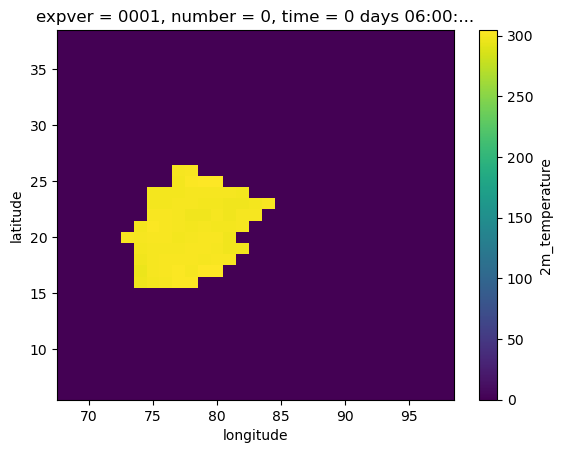

In [10]:
dbase_region = mask_dbase_regions(eval_targets)
plot_sample_from_ds(dbase_region, var_name='2m_temperature')

In [11]:
import math
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
# from utils import mask_dbase_india_buffer

def accum_time_and_plot_ds(
    *data_objs,
    var_name=None,
    indiaplot: bool = True,
    lat_range: tuple[float, float] = (6, 38),
    lon_range: tuple[float, float] = (68, 98),
    max_datasets: int = 6,
    cmap: str = "viridis",
    isdiff: bool = False,
    india_shape: bool = False,
    region_shape: str = None
):
    """
    Sum over time and plot each xarray object on its own map,
    using `plot_label` attr (if present) for the title.
    """
    n = len(data_objs)
    if n == 0:
        raise ValueError("Must pass at least one DataArray or Dataset.")
    if n > max_datasets:
        raise ValueError(f"Can only plot up to {max_datasets} objects; you passed {n}.")

    # Build per-input var_name list
    if isinstance(var_name, (list, tuple)):
        if len(var_name) != n:
            raise ValueError("`var_name` list must match number of inputs.")
        var_names = list(var_name)
    else:
        var_names = [var_name] * n

    # First pass: process each, track global vmin/vmax
    processed = []
    gmin, gmax = np.inf, -np.inf

    for ds, vname in zip(data_objs, var_names):
        if india_shape:
            ds = mask_dbase_india_buffer(ds)
        if region_shape:
            ds = mask_dbase_regions(ds, region_name='West_Central')
        # 1) extract DataArray
        if isinstance(ds, xr.Dataset):
            if vname is None:
                raise ValueError("You must supply `var_name` for each Dataset.")
            da = ds[vname]
        else:
            da = ds  # assume DataArray

        # 2) detect time dim
        if "time" in da.dims:
            tdim = "time"
        elif "valid_time" in da.dims:
            tdim = "valid_time"
        else:
            tdim = next(d for d in da.dims if da[d].dtype.kind == "M")

        # 3) sum over time
        da_sum = da.sum(dim=tdim)

        # 4) pick up your custom label, or fall back to da.name
        label = ds.attrs.get("plot_label", None) or da.name or vname or f"ds{len(processed)+1}"
        da_sum.name = label  # this becomes the plot title

        # 5) detect lat/lon names and subset if needed
        latn = "latitude" if "latitude" in da_sum.coords else "lat"
        lonn = "longitude" if "longitude" in da_sum.coords else "lon"
        if indiaplot:
            mn_lat, mx_lat = lat_range
            mn_lon, mx_lon = lon_range
            asc = da_sum[latn].values[0] < da_sum[latn].values[-1]
            if asc:
                da_sum = da_sum.sel(**{latn: slice(mn_lat, mx_lat),
                                      lonn: slice(mn_lon, mx_lon)})
            else:
                da_sum = da_sum.sel(**{latn: slice(mx_lat, mn_lat),
                                      lonn: slice(mn_lon, mx_lon)})

        # 6) update global vmin/vmax
        arr = da_sum.values
        gmin = min(gmin, float(np.nanmin(arr)))
        gmax = max(gmax, float(np.nanmax(arr)))

        processed.append(da_sum)

    
    # Determine shared color scale
    if isdiff:
        abs_max = max(abs(gmin), abs(gmax))
        cmin, cmax = -abs_max, abs_max
        cmap_to_use = 'bwr'
    else:
        cmin, cmax = gmin, gmax
        cmap_to_use = cmap


    # Create subplot grid
    ncols = min(n, 3)
    nrows = math.ceil(n / ncols)
    fig, axs = plt.subplots(nrows, ncols,
                            figsize=(5 * ncols, 4 * nrows),
                            constrained_layout=True)
    axs = axs.flatten()

    # Plot each with the common color scale
    for i, da_sum in enumerate(processed):
        ax = axs[i]
        im = da_sum.plot(ax=ax,
                         vmin=cmin,
                         vmax=cmax,
                         cmap=cmap_to_use,
                         add_colorbar=False)
        ax.set_title(da_sum.name)

    # Single shared colorbar
    cbar = fig.colorbar(im,
                        ax=axs[:n],
                        orientation="vertical",
                        label=getattr(processed[0], "units", None))

    # Hide any unused axes
    for ax in axs[n:]:
        ax.set_visible(False)

    return fig, axs

In [12]:
eval_targets = eval_targets.assign_attrs(plot_label="Eval Targets")
predictions_base = predictions_base.assign_attrs(plot_label="Base")
predictions_ft1 = predictions_ft1.assign_attrs(plot_label="Finetuned 1")
predictions_ft2 = predictions_ft2.assign_attrs(plot_label="Finetuned 2")

In [13]:
"lat" in eval_targets.coords

True

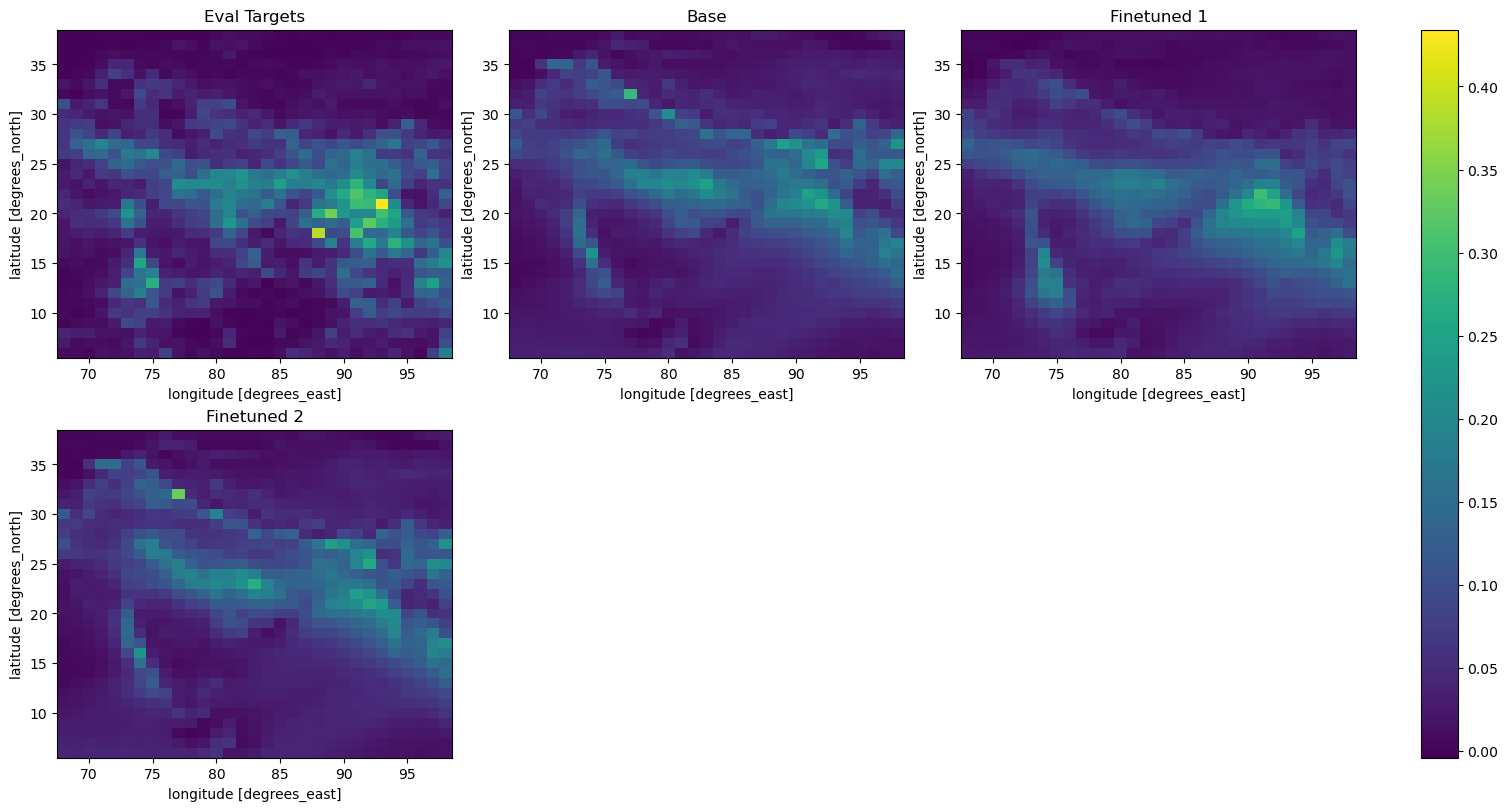

In [15]:
fig, ax = accum_time_and_plot_ds(eval_targets, predictions_base, predictions_ft1, predictions_ft2,
                              var_name="total_precipitation_6hr",
                              indiaplot=True, india_shape=False, region_shape=None)

In [16]:
eval_targets

<xarray.Dataset> Size: 606MB
Dimensions:                  (batch: 1, time: 28, lat: 181, lon: 360, level: 13)
Coordinates:
    expver                   (time) <U4 448B '0001' '0001' ... '0001' '0001'
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 104B 50 100 150 200 ... 850 925 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float32 7MB 227.3 ... 272.8
    mean_sea_level_pressure  (batch, time, lat, lon) float32 7MB 1.017e+05 .....
    10m_v_component_of_wind  (batch, time, lat, lon) float32 7MB -2.76 ... 0....
    10m_u_component_of_wind  (batch, time, lat, lon) float32 7MB 3.953 ... 7.348
    total_precipitation_6hr  (batch, time, lat, lon) float32 7MB 5.054e-05 .....
    temperature              (batch, time, level, lat, lon) float32 95MB 183....
    geopotential             (batch, time, level, lat, lon) float32 95MB 1.81...
    u_component_of_wind      (batch, time, level, lat, lon) float32 95MB -0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float32 95MB -0.0...
    vertical_velocity        (batch, time, level, lat, lon) float32 95MB 0.01...
    specific_humidity        (batch, time, level, lat, lon) float32 95MB 1.29...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts
    plot_label:              Eval Targets

In [40]:
diff_base = (
    eval_targets - predictions_base
).assign_attrs(plot_label="Diff: Eval Targets - Base")

diff_finetuned = (
    eval_targets - predictions_ft2
).assign_attrs(plot_label="Diff: Eval Targets - Finetuned 2")

diff_of_diffs = (
    diff_finetuned - diff_base
).assign_attrs(plot_label="Diff Fine - Diff Base")

preds_diff = (
    predictions_base - predictions_ft2
).assign_attrs(plot_label="Base - Finetuned 2")




E0730 17:57:23.968795 2533325 pjrt_stream_executor_client.cc:2985] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Failed to allocate request for 6.96MiB (7297920B) on device ordinal 0


ValueError: RESOURCE_EXHAUSTED: Failed to allocate request for 6.96MiB (7297920B) on device ordinal 0

In [ ]:
# 2) now plot all four at once
fig, axs = accum_time_and_plot_ds(
    diff_base,
    diff_finetuned,
    diff_of_diffs,
    preds_diff,
    var_name='total_precipitation_6hr',
    indiaplot=True,
    isdiff=True,
    india_shape=False,
    region_shape='West_Central'
)

In [25]:
def plot_rmse_time_series(
    eval_targets,
    *predictions,
    var_name=None,
    ax=None
):
    """
    Compute and plot RMSE vs time for multiple predictions against eval_targets,
    and plot total precipitation from eval_targets on a secondary y-axis.
    """
    eval_targets = mask_dbase_regions(eval_targets)
    if 'latitude' in eval_targets.coords:
        eval_targets = eval_targets.rename({'latitude': 'lat', 'longitude': 'lon'})
    # extract target DataArray
    if isinstance(eval_targets, xr.Dataset):
        if var_name is None:
            raise ValueError("`var_name` required when eval_targets is a Dataset.")
        target_da = eval_targets[var_name]
    else:
        target_da = eval_targets
    # detect time dim
    if "time" in target_da.dims:
        tdim = "time"
    elif "valid_time" in target_da.dims:
        tdim = "valid_time"
    else:
        tdim = next(d for d in target_da.dims if target_da[d].dtype.kind == "M")
    # compute total precipitation series
    # other_dims = [d for d in target_da.dims if d != tdim]
    total_precip = target_da.sum(dim=('lat', 'lon')) #if other_dims else target_da
    tgt_label = eval_targets.attrs.get("plot_label") or target_da.name or "Eval Targets"
    total_precip.name = tgt_label
    # compute RMSE series for each prediction
    rmse_series = {}
    for pred in predictions:
        pred = mask_dbase_india_buffer(pred)
        if isinstance(pred, xr.Dataset):
            if var_name is None:
                raise ValueError("`var_name` required when predictions are Datasets.")
            pred_da = pred[var_name]
        else:
            pred_da = pred
        # align and compute squared error
        tgt_al, pr_al = xr.align(target_da, pred_da)
        se = (pr_al - tgt_al) ** 2
        # collapse non-time dims
        collapse = [d for d in se.dims if d != tdim]
        mse = se.mean(dim=collapse) if collapse else se
        rmse = np.sqrt(mse)
        lbl = pred.attrs.get("plot_label") or pred_da.name or "Prediction"
        rmse.name = lbl
        rmse_series[lbl] = rmse
    # plotting
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
    # plot RMSE on primary y-axis
    for lbl, series in rmse_series.items():
        series.plot(ax=ax, label=lbl)
    ax.set_xlabel(tdim)
    ax.set_ylabel('RMSE')
    # secondary axis for total precipitation
    ax2 = ax.twinx()
    total_precip.plot(ax=ax2, label=total_precip.name, color='gray', linestyle='--')
    ax2.set_ylabel('Total Precipitation')
    # combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax.set_title('RMSE Time Series and Total Precipitation')
    return fig, ax

In [39]:
time_slice = slice(None, None)
rmse_series = plot_rmse_time_series(eval_targets.isel(time=time_slice), predictions_base.isel(time=time_slice), predictions_ft1.isel(time=time_slice), predictions_ft2.isel(time=time_slice), var_name='total_precipitation_6hr')
rmse_series

E0730 17:55:09.883934 2533325 pjrt_stream_executor_client.cc:2985] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Failed to allocate request for 6.96MiB (7297920B) on device ordinal 0


ValueError: RESOURCE_EXHAUSTED: Failed to allocate request for 6.96MiB (7297920B) on device ordinal 0

In [90]:
target_da = eval_targets['total_precipitation_6hr']
pred_da = predictions_base['total_precipitation_6hr']

In [95]:
rmse_series = {}
se = (pred_da - target_da)**2
mse = se.mean(dim=('lat', 'lon'))
rmse = np.sqrt(mse)

label = predictions_base.attrs.get('plot_label', pred_da.name)
rmse.name = label
rmse_series[label] = rmse

In [97]:
if ax is None:
    fig, ax = plt.subplots()
else:
    fig = ax.figure

for label, rmse in rmse_series.items():
    rmse.plot.line(ax=ax, label=label)

ax.set_xlabel('time')
ax.set_ylabel('RMSE')
ax.legend()
ax.set_title('RMSE Time Series')

AttributeError: 'numpy.ndarray' object has no attribute 'figure'

In [83]:
fig, ax = plot_rmse_time_series(eval_targets, [predictions_base, predictions_ft1, predictions_ft2], var_name='total_precipitation_6hr')

TypeError: cannot directly convert an xarray.Dataset into a numpy array. Instead, create an xarray.DataArray first, either with indexing on the Dataset or by invoking the `to_dataarray()` method.

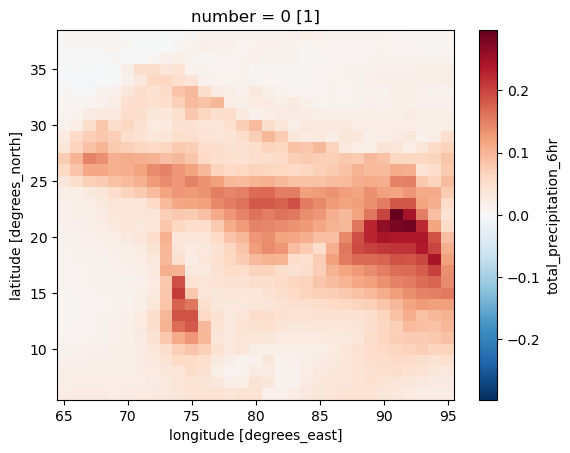

In [47]:
test_ds = predictions_ft2
test_ds.sum(dim='time').sel(lat=slice(6, 38), lon=slice(65, 95))['total_precipitation_6hr'].plot()

In [2]:

for init_idx, init_date in enumerate(tqdm(initialization_dates[:2], desc="Evaluating Forecasts")):
    logging.info(f"Processing initialization date: {init_date}")

    # 1. Load data for this initialization
    try:
        # end_slice is a week after the starting. we need the start_slice to be behind by 6 hours cause graphcast needs 2 timesteps initially
        start_slice = init_date - pd.Timedelta(hours=6)
        end_slice = init_date + pd.Timedelta(days=7)
        start_slice -= select_time_eval.datetime.values[0][0]
        end_slice -= select_time_eval.datetime.values[0][0]

        from dask.diagnostics import ProgressBar
        with ProgressBar():
            eval_sim_data = select_time_eval.sel(time=slice(start_slice, end_slice)).compute()

        if eval_sim_data.sizes["time"] < 2:
            logging.warning(f"Not enough data for initialization {init_date}. Found {eval_sim_data.sizes['time']} steps. Skipping.")
            continue
    except Exception as e:
        logging.warning(f"Could not load data for {init_date}: {e}. Skipping.")
        continue

    # 2. Prepare inputs, targets, and forcings for a 7-day rollout
    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
        eval_sim_data, target_lead_times=target_lead_times_slice, **dataclasses.asdict(task_config))
    
    print("Eval Inputs:   ", eval_inputs.dims.mapping)
    print("Eval Targets:  ", eval_targets.dims.mapping)
    print("Eval Forcings: ", eval_forcings.dims.mapping)

    if (eval_inputs.dims.mapping['time'] != 2):
        print("\nError in extracting inputs targets and forcings\n")
        continue

    if eval_targets.sizes['time'] < MAX_FORECAST_STEPS:
        logging.warning(f"Not enough target data for a 7-day forecast from {init_date}. Have {eval_targets.sizes['time']} steps. Skipping.")
        continue

    targets_template = eval_targets * np.nan
    ground_truth_var = eval_targets[eval_vars]

    # 3. Run all Graphcast models
    logging.debug(f"Running Graphcast models for {init_date}")
    print("Base run")
    predictions_base = run_model(params, state, eval_inputs, targets_template, eval_forcings)
    print("Finetuned 1")
    predictions_ft1 = run_model(new_params1, state, eval_inputs, targets_template, eval_forcings)
    print("Finetuned 2")
    predictions_ft2 = run_model(new_params2, state, eval_inputs, targets_template, eval_forcings)
    
    models_to_eval = {
        'Graphcast_Base': predictions_base,
        'Graphcast_Finetuned1': predictions_ft1,
        'Graphcast_Finetuned2': predictions_ft2,
    }

    # 4. Load, regrid, and align HRES forecast
    hres_predictions = None
    hres_file_path = hres_files_map.get(init_date.to_pydatetime().replace(hour=0, minute=0, second=0, microsecond=0))
    if hres_file_path:
        try:
            logging.debug(f"Processing HRES file: {hres_file_path}")
            hres_ds = xr.open_dataset(hres_file_path, engine='cfgrib')
            hres_regridded = regrid_hres_fine_to_coarse(hres_ds, variable='tp', coarse_resolution=1.0)
            hres_predictions = hres_regridded.drop_vars({'time'}).rename({'step': 'time'}).isel(time=slice(1,None)).assign_coords(time=eval_targets.time)
            models_to_eval['HRES'] = hres_predictions
        except Exception as e:
            logging.warning(f"Failed to process HRES file {hres_file_path}: {e}")
    else:
        logging.warning(f"No HRES file found for init date {init_date}")

    # 5. Calculate total rainfall for ground truth
    ground_truth_rainfall_totals = calculate_total_rainfall(ground_truth_var).values

    # 6. Calculate MSE and total rainfall for each model and forecast horizon
    for model_name, predictions in tqdm(models_to_eval.items(), desc="MSE Calc"):
        if eval_vars in predictions:
            pred_var = predictions[eval_vars]
        else:
            pred_var = predictions

        times = pred_var.time.values
        
        # Calculate total rainfall for this model
        model_rainfall_totals = calculate_total_rainfall(pred_var).values
            
        for step_idx, timestep in enumerate(times):
            # Slice predictions and targets to the current forecast horizon
            pred_sliced = pred_var.sel(time=timestep)
            targ_sliced = ground_truth_var.sel(time=timestep)
            
            # MSE calculation
            mse = float(((pred_sliced - targ_sliced)**2).mean())

            # Store MSE result
            result_row = {
                'init_date': init_date.strftime('%Y-%m-%d %H:%M:%S'),
                'forecast_horizon_times': timestep,
                'forecast_step': step_idx + 1,
                'model': model_name,
                'mse': mse,
                'total_rainfall_pred': float(model_rainfall_totals[step_idx]),
                'total_rainfall_truth': float(ground_truth_rainfall_totals[step_idx])
            }
            all_results.append(result_row)

            # Store rainfall data for plotting
            rainfall_row = {
                'init_date': init_date.strftime('%Y-%m-%d %H:%M:%S'),
                'forecast_step': step_idx + 1,
                'model': model_name,
                'total_rainfall': float(model_rainfall_totals[step_idx])
            }
            all_rainfall_totals.append(rainfall_row)

            pd.DataFrame([result_row]).to_csv('skill_score.csv', mode='a', index=False)

            logging.debug(f"Result: {init_date}, {model_name}, {step_idx+1}-step MSE = {mse:.6f}, Total Rainfall = {model_rainfall_totals[step_idx]:.2f}")

    # 7. Create spatial plots for selected forecast horizons (every 7 steps = daily)
    if init_idx % 5 == 0:  # Create plots for every 5th initialization to save space
        for step in [3, 6, 12, 18, 27]:  # Selected forecast steps
            if step < len(times):
                timestep = times[step]
                targ_sliced = ground_truth_var.sel(time=timestep)
                
                # Get predictions for this timestep
                preds_for_plotting = {}
                for model_name, predictions in models_to_eval.items():
                    if eval_vars in predictions:
                        pred_var = predictions[eval_vars]
                    else:
                        pred_var = predictions
                    preds_for_plotting[model_name] = pred_var.sel(time=timestep)
                
                # Create plots
                step_plots_dir = f"{plots_dir}/init_{init_date.strftime('%Y%m%d')}"
                create_rainfall_plots(targ_sliced, preds_for_plotting, init_date, step + 1, step_plots_dir)

# 8. Save all results to CSV files
logging.info("Evaluation loop finished. Saving results to CSV.")
results_df = pd.DataFrame(all_results)
rainfall_df = pd.DataFrame(all_rainfall_totals)

# Add ground truth rainfall to rainfall dataframe
ground_truth_rainfall_df = results_df.groupby(['init_date', 'forecast_step']).agg({
    'total_rainfall_truth': 'first'
}).reset_index()
ground_truth_rainfall_df['model'] = 'Ground_Truth'
ground_truth_rainfall_df['total_rainfall'] = ground_truth_rainfall_df['total_rainfall_truth']
ground_truth_rainfall_df = ground_truth_rainfall_df[['init_date', 'forecast_step', 'model', 'total_rainfall']]

rainfall_combined_df = pd.concat([rainfall_df, ground_truth_rainfall_df], ignore_index=True)

output_dir = os.path.dirname(args.output_csv_path)
if output_dir:
    os.makedirs(output_dir, exist_ok=True)

results_df.to_csv(args.output_csv_path, index=False)
rainfall_combined_df.to_csv(args.output_csv_path.replace('.csv', '_rainfall.csv'), index=False)

# 9. Create rainfall and MSE comparison plots
logging.info("Creating summary plots...")

# Plot MSE vs forecast step for all models
plt.figure(figsize=(12, 8))
mse_summary = results_df.groupby(['forecast_step', 'model']).agg({'mse': 'mean'}).reset_index()

for model in mse_summary['model'].unique():
    model_data = mse_summary[mse_summary['model'] == model]
    plt.plot(model_data['forecast_step'], model_data['mse'], marker='o', label=model, linewidth=2)

plt.xlabel('Forecast Step (6-hourly)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('MSE vs Forecast Lead Time', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./evaluation_results/mse_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

# Plot total rainfall vs forecast step for all models
plt.figure(figsize=(12, 8))
rainfall_summary = rainfall_combined_df.groupby(['forecast_step', 'model']).agg({'total_rainfall': 'mean'}).reset_index()

for model in rainfall_summary['model'].unique():
    model_data = rainfall_summary[rainfall_summary['model'] == model]
    linestyle = '--' if model == 'Ground_Truth' else '-'
    linewidth = 3 if model == 'Ground_Truth' else 2
    plt.plot(model_data['forecast_step'], model_data['total_rainfall'], 
             marker='o', label=model, linestyle=linestyle, linewidth=linewidth)

plt.xlabel('Forecast Step (6-hourly)', fontsize=12)
plt.ylabel('Total Rainfall over India (mm)', fontsize=12)
plt.title('Total Rainfall vs Forecast Lead Time', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./evaluation_results/rainfall_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

# Combined plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot MSE on left y-axis
color = 'tab:red'
ax1.set_xlabel('Forecast Step (6-hourly)', fontsize=12)
ax1.set_ylabel('Mean Squared Error', color=color, fontsize=12)
for model in mse_summary['model'].unique():
    model_data = mse_summary[mse_summary['model'] == model]
    ax1.plot(model_data['forecast_step'], model_data['mse'], 
             marker='o', label=f'{model} (MSE)', color=color, alpha=0.7, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

# Plot rainfall on right y-axis
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Total Rainfall over India (mm)', color=color, fontsize=12)
for model in rainfall_summary['model'].unique():
    model_data = rainfall_summary[rainfall_summary['model'] == model]
    linestyle = '-' if model == 'Ground_Truth' else ':'
    linewidth = 3 if model == 'Ground_Truth' else 2
    ax2.plot(model_data['forecast_step'], model_data['total_rainfall'], 
             marker='s', label=f'{model} (Rainfall)', color=color, alpha=0.8, 
             linestyle=linestyle, linewidth=linewidth)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('MSE and Total Rainfall vs Forecast Lead Time', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('./evaluation_results/combined_mse_rainfall.png', dpi=300, bbox_inches='tight')
plt.close()

logging.info(f"Evaluation complete. Results saved to {args.output_csv_path}")
logging.info("Summary plots saved in ./evaluation_results/")
print("\n--- Sample of Evaluation Results ---")
print(results_df.head())
print("\n--- Sample of Rainfall Results ---")
print(rainfall_combined_df.head())
print("------------------------------------\n")

Evaluating Forecasts:   0%|          | 0/2 [00:00<?, ?it/s]2025-07-24 15:59:59,135 - INFO - Processing initialization date: 2024-08-01 00:00:00


[########################################] | 100% Completed | 1.98 sms


2025-07-24 16:00:02,540 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-07-24 16:00:02,548 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Base run
Finetuned 1
Finetuned 2


/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built


/tmp/ipykernel_3724769/1500166368.py:102: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'total_rainfall_pred': float(model_rainfall_totals[step_idx]),
Evaluating Forecasts:   0%|          | 0/2 [01:35<?, ?it/s]


TypeError: only length-1 arrays can be converted to Python scalars